# 📊 Phase 1: Python for Data
### Your Data Analyst Curriculum — Part 2

---

**What you'll practice here:**
- Loading a real dataset with `pandas`
- Exploring, filtering, and grouping tabular data
- Computing stats with `numpy`
- Making your first charts
- One capstone exercise that puts it all together

**Prerequisites:** You've completed the deep dive notebook (Sections 1–5). Variables, lists, loops, comprehensions, and functions should feel comfortable.

---

## 🔧 Section 1: Setup

Import the four libraries. You know what these are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries loaded.')

Libraries loaded.


## 🐍 Section 2: Quick Python Refresher

A fast recap of what you built in the deep dive — variables, lists, loops, comprehensions, functions. Run these cells to load the functions we'll reuse later.

### 2a. Variables & Types

In [2]:
name = "Pidjin"
age = 30
is_smoker = False
bmi = 24.7

print(f"Hello, {name}. BMI: {bmi}. Smoker: {is_smoker}.")
print(f"Type of bmi: {type(bmi)}")

Hello, Pidjin. BMI: 24.7. Smoker: False.
Type of bmi: <class 'float'>


### 2b. Lists

In [3]:
charges = [1200.50, 3400.00, 875.25, 12000.99, 450.00]

print(f"First: {charges[0]}")
print(f"Last: {charges[-1]}")
print(f"Count: {len(charges)}")
print(f"Average: {sum(charges) / len(charges):.2f}")

First: 1200.5
Last: 450.0
Count: 5
Average: 3585.35


### 2c. Loops

In [4]:
regions = ['northeast', 'northwest', 'southeast', 'southwest']

for i, region in enumerate(regions):
    print(f"{i}: {region}")

0: northeast
1: northwest
2: southeast
3: southwest


### 2d. List Comprehensions

In [5]:
charges = [1200.50, 3400.00, 875.25, 12000.99, 450.00]

charges_with_tax = [c * 1.1 for c in charges]
high_charges = [c for c in charges if c > 1000]

print(f"With tax: {charges_with_tax}")
print(f"Over $1000: {high_charges}")

With tax: [1320.5500000000002, 3740.0000000000005, 962.7750000000001, 13201.089, 495.00000000000006]
Over $1000: [1200.5, 3400.0, 12000.99]


### 2e. Functions

Run this cell — we'll reuse `classify_bmi` later when working with the real dataset.

In [6]:
def classify_bmi(bmi):
    """Returns BMI category as a string."""
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def classify_age(age):
    """Returns age group as a string."""
    if age < 30:
        return 'Young'
    elif age < 60:
        return 'Middle-aged'
    else:
        return 'Senior'

# Quick test
test_bmis = [17.0, 22.5, 27.3, 34.1]
for b in test_bmis:
    print(f"BMI {b} → {classify_bmi(b)}")

BMI 17.0 → Underweight
BMI 22.5 → Normal
BMI 27.3 → Overweight
BMI 34.1 → Obese


### 🏋️ Exercise 1

Write a function called `classify_age` that takes an age and returns:
- `'Young'` if under 30
- `'Middle-aged'` if 30–59
- `'Senior'` if 60 or above

Then test it on ages: `[22, 35, 61, 45, 28]`

*(Note: `classify_age` is already defined above — this exercise is asking you to write it yourself from scratch in the cell below, then compare.)*

In [7]:
# Your code here
def classify_age(age):
  if age < 30:
    return 'Young'
  elif age < 60:
    return 'Middle-aged'
  else:
    return 'Senior'

test_ages = [22, 35, 61, 45, 28]

for a in test_ages:
  print(f"Age {a} is {classify_age(a)}")

Age 22 is Young
Age 35 is Middle-aged
Age 61 is Senior
Age 45 is Middle-aged
Age 28 is Young


---
## 🐼 Section 3: Pandas — Working with Tables

A pandas `DataFrame` is a table — rows and columns, like a spreadsheet. This is the core tool for data analysts.

### 3a. Load the Dataset

We're using the **insurance dataset** — 1,338 rows of patient data including age, BMI, smoker status, region, and yearly medical charges.

Instead of fetching a CSV from a URL that might go down, we load it from seaborn's built-in collection — guaranteed to always work.

In [28]:
import urllib.request
import io

url = 'https://raw.githubusercontent.com/BrianCarela/Data-analytics-practice/refs/heads/main/02_pandas_and_numpy/data/02_01_insurance.csv'
try:
    response = urllib.request.urlopen(url)
    lines = [l.decode('utf-8') for l in response]
    df = pd.read_csv(io.StringIO('\n'.join(lines)))
    print('Loaded from GitHub.')
except Exception as e:
    print(f'Failed: {e}')

print(f'Shape: {df.shape}')
print(f'Dtypes:\n{df.dtypes}')
# df.head()

Loaded from GitHub.
Shape: (1338, 7)
Dtypes:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


### 3b. First Look — Always Do This First

Every time you get a new dataset, run these three things before anything else. This is the standard opening move for any data analyst.

In [9]:
# 1. Column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
# 2. Summary statistics on all numeric columns
# count, mean, std, min, 25th percentile, median, 75th percentile, max
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
# 3. Check for missing values
# In real datasets, missing data is everywhere — always check
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### 3c. Selecting Data

Two syntaxes to know:
- `df['column']` — single column → returns a **Series** (like a labeled list)
- `df[['col1', 'col2']]` — multiple columns → returns a **DataFrame**

In [12]:
# Single column — Series
ages = df['age']
print(ages.head())
print(f"\nAverage age: {ages.mean():.1f}")
print(f"Min: {ages.min()}, Max: {ages.max()}")

0    19
1    18
2    28
3    33
4    32
Name: age, dtype: int64

Average age: 39.2
Min: 18, Max: 64


In [13]:
# Multiple columns — DataFrame
subset = df[['age', 'bmi', 'charges']]
subset.head()

,age,bmi,charges
0,19,27.900,16884.92400
1,18,33.770,1725.55230
2,28,33.000,4449.46200
3,33,22.705,21984.47061
4,32,28.880,3866.85520


### 3d. Filtering Rows

This is SQL's `WHERE` clause. You put a condition inside `df[...]` and only the matching rows come back.

**Important:** Use `&` for AND and `|` for OR — not `and`/`or`. And wrap each condition in `()`.

In [14]:
# Smokers only
smokers = df[df['smoker'] == 'yes']
non_smokers = df[df['smoker'] == 'no']

print(f"Smoker count: {len(smokers)}")
print(f"Average charge (smokers):     ${smokers['charges'].mean():,.2f}")
print(f"Average charge (non-smokers): ${non_smokers['charges'].mean():,.2f}")
print(f"Smokers pay {smokers['charges'].mean() / non_smokers['charges'].mean():.1f}x more on average")

Smoker count: 274
Average charge (smokers):     $32,050.23
Average charge (non-smokers): $8,434.27
Smokers pay 3.8x more on average


In [15]:
# Multiple conditions: smokers AND age over 40
# Each condition wrapped in () — required when using & or |
older_smokers = df[(df['smoker'] == 'yes') & (df['age'] > 40)]
print(f"Older smokers (40+): {len(older_smokers)} people")
print(f"Their average charge: ${older_smokers['charges'].mean():,.2f}")
older_smokers.head()

Older smokers (40+): 125 people
Their average charge: $36,171.17


,age,sex,bmi,children,smoker,region,charges
11,62,female,26.290,0,yes,southeast,27808.72510
39,60,male,39.900,0,yes,southwest,48173.36100
52,48,male,28.000,1,yes,southwest,23568.27200
55,58,male,36.955,2,yes,northwest,47496.49445
58,53,female,22.880,1,yes,southeast,23244.79020


### 3e. GroupBy — Summarizing by Category

This is SQL's `GROUP BY`. The most important pandas operation for data analysts.

Pattern: `df.groupby('category_column')['value_column'].aggregation()`

In [16]:
# Average charges by region — sorted highest to lowest
df.groupby('region')['charges'].mean().sort_values(ascending=False)

,charges
region,
southeast,14735.411438
northeast,13406.384516
northwest,12417.575374
southwest,12346.937377


In [17]:
# Multiple stats at once using .agg()
df.groupby('smoker')['charges'].agg(['mean', 'median', 'min', 'max', 'count'])

,mean,median,min,max,count
smoker,,,,,
no,8434.268298,7345.40530,1121.8739,36910.60803,1064
yes,32050.231832,34456.34845,12829.4551,63770.42801,274


In [18]:
# Group by TWO columns — creates a cross-tab view
# .unstack() pivots the inner group into columns for easier reading
df.groupby(['region', 'smoker'])['charges'].mean().round(2).unstack()

smoker,no,yes
region,,
northeast,9165.53,29673.54
northwest,8556.46,30192.00
southeast,8032.22,34845.00
southwest,8019.28,32269.06


### 3f. Adding New Columns

`.apply()` runs a function on every row of a column — this is how you bring your custom functions into pandas.

In [19]:
# Apply classify_bmi to every value in the 'bmi' column
df['bmi_category'] = df['bmi'].apply(classify_bmi)

# value_counts() shows how many rows fall into each category
print('BMI category distribution:')
print(df['bmi_category'].value_counts())

BMI category distribution:
bmi_category
Obese          707
Overweight     386
Normal         225
Underweight     20
Name: count, dtype: int64


In [20]:
# Now we can groupby our new column
df.groupby('bmi_category')['charges'].mean().sort_values(ascending=False)

,charges
bmi_category,
Obese,15552.335469
Overweight,10987.509891
Normal,10409.337709
Underweight,8852.200585


### 🏋️ Exercise 2

Use the `classify_age` function (defined in Section 2e) to:
1. Add an `age_group` column to `df` using `.apply()`
2. Find the average charges for each age group using `.groupby()`
3. Print a sentence saying which age group has the highest average charges

*Hint: `.idxmax()` on a Series returns the index label of the maximum value.*

In [32]:
# Your code here
# 1
df['age_group'] = df['age'].apply(classify_age)

# 2
avg_age_group_charge = df.groupby('age_group')['charges'].mean()

# 3
print(f"The age group with the highest charges on average is {avg_age_group_charge.idxmax()}s")






The age group with the highest charges on average is Seniors


---
## 🔢 Section 4: NumPy — Math & Stats

NumPy works on arrays of numbers — fast, vectorized math. Pandas uses it internally.

### 4a. Arrays vs Lists

In [22]:
charges_list = [1200.50, 3400.00, 875.25, 12000.99, 450.00]
charges_array = np.array(charges_list)

# Math on an array applies to EVERY element at once — no loop needed
print('Array * 1.1:')
print(charges_array * 1.1)

# Boolean mask — True/False for each element
print('\nArray > 1000:')
print(charges_array > 1000)

# Use the mask to filter — only keeps True positions
print('\nFiltered (> 1000):')
print(charges_array[charges_array > 1000])

Array * 1.1:
[ 1320.55   3740.      962.775 13201.089   495.   ]

Array > 1000:
[ True  True False  True False]

Filtered (> 1000):
[ 1200.5   3400.   12000.99]


### 4b. Descriptive Stats

These are the stats you'll cite constantly as an analyst. Know them cold.

In [23]:
# .values converts a pandas Series to a numpy array
charges = df['charges'].values

print(f"Count:    {len(charges)}")
print(f"Mean:     ${np.mean(charges):,.2f}")
print(f"Median:   ${np.median(charges):,.2f}")
print(f"Std Dev:  ${np.std(charges):,.2f}")
print(f"Min:      ${np.min(charges):,.2f}")
print(f"Max:      ${np.max(charges):,.2f}")
print()
print(f"25th percentile: ${np.percentile(charges, 25):,.2f}")
print(f"75th percentile: ${np.percentile(charges, 75):,.2f}")
iqr = np.percentile(charges, 75) - np.percentile(charges, 25)
print(f"IQR (middle 50% spread): ${iqr:,.2f}")

Count:    1338
Mean:     $13,270.42
Median:   $9,382.03
Std Dev:  $12,105.48
Min:      $1,121.87
Max:      $63,770.43

25th percentile: $4,740.29
75th percentile: $16,639.91
IQR (middle 50% spread): $11,899.63


**⚠️ Analyst Insight — Mean vs Median:**

The mean is higher than the median. That means the distribution is *right-skewed* — a small number of very high charges are pulling the average up. The median is more representative of a typical patient.

If you reported only the mean to a non-technical audience, you'd be overstating what most people actually pay. This is one of the most common mistakes in data storytelling.

---
## 📈 Section 5: First Charts

The goal here is to *see* the data you've been computing. Don't worry about memorizing the syntax — focus on what the chart reveals.

### 5a. Distribution of Charges

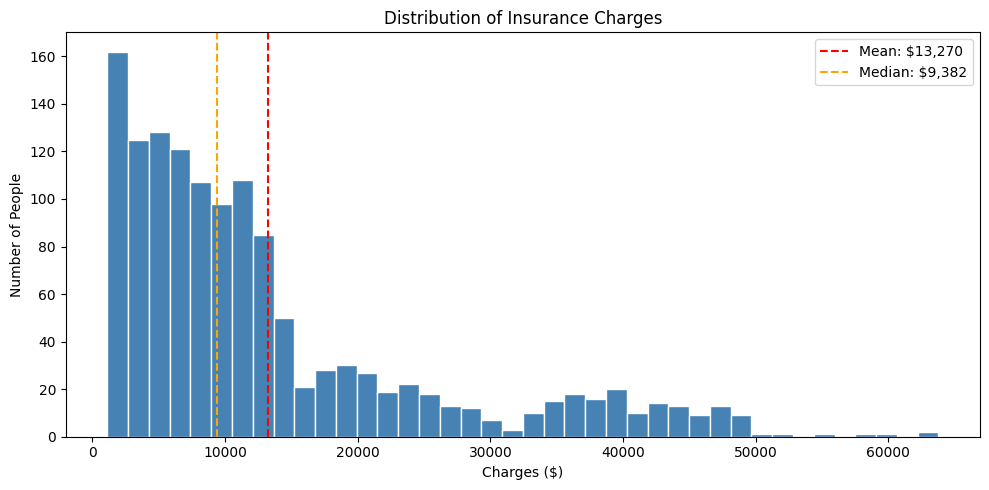

The long right tail shows a small group of very high-cost patients pulling the mean up.


In [24]:
plt.figure(figsize=(10, 5))
plt.hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
plt.axvline(df['charges'].mean(),
            color='red', linestyle='--',
            label=f"Mean: ${df['charges'].mean():,.0f}")
plt.axvline(df['charges'].median(),
            color='orange', linestyle='--',
            label=f"Median: ${df['charges'].median():,.0f}")
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Number of People')
plt.legend()
plt.tight_layout()
plt.show()
print('The long right tail shows a small group of very high-cost patients pulling the mean up.')

### 5b. Smokers vs Non-Smokers

A **box plot** shows the median, the middle 50% of data (the box), and outliers (the dots). Great for comparing groups.

/tmp/ipykernel_566/4091783630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')


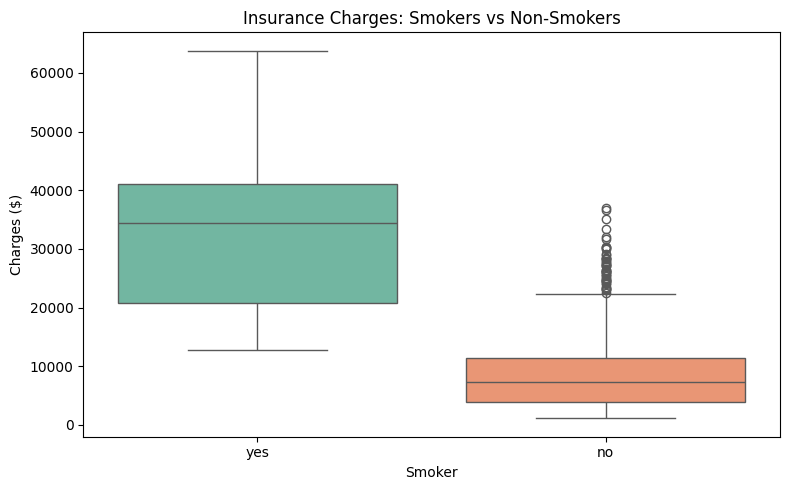

The entire smoker box sits above the non-smoker box — smoking is the biggest cost driver.


In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')
plt.title('Insurance Charges: Smokers vs Non-Smokers')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()
print('The entire smoker box sits above the non-smoker box — smoking is the biggest cost driver.')

### 5c. Age vs Charges

A **scatter plot** shows the relationship between two numeric variables. Color adds a third dimension.

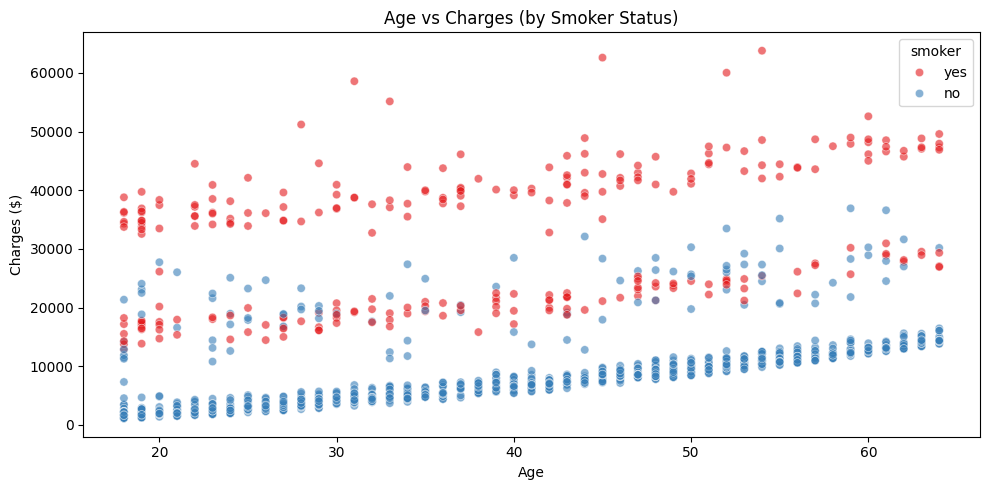

Notice the two distinct bands for smokers — charges increase with age, but smokers start higher.


In [26]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='age', y='charges',
                hue='smoker', alpha=0.6, palette='Set1')
plt.title('Age vs Charges (by Smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()
print('Notice the two distinct bands for smokers — charges increase with age, but smokers start higher.')

---
## 🏁 Section 6: Milestone Exercise

This is your Phase 1 capstone. Use everything you've learned.

**The question:** *Which combination of factors is most associated with high insurance charges?*

1. What is the average charge for someone who is a smoker AND has an `'Obese'` BMI?
2. Compare that to a non-smoker with a `'Normal'` BMI.
3. How many times more expensive is the high-risk group?
4. Write 2–3 sentences (as a print statement) describing your finding as if presenting to a manager.

*Analyst mindset: find a number, give it meaning, communicate it clearly.*

In [27]:
# Your code here


---
## ✅ Phase 1 Complete

When you finish the milestone, you're ready for **Phase 2: EDA & Visualization.**

Phase 2 covers:
- Reading and explaining every part of a chart
- Distributions, skew, and outlier detection
- Correlation matrices — where your old notebook left off
- Writing analyst-style observations under each chart
- Telling a data story from scratch

**Push this to GitHub and send me the raw link when you finish the milestone. 🚀**